# Steam Game Reception Prediction

---
## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack, csr_matrix

PALETTE     = sns.color_palette('colorblind', 8)

# Reception class colors
C_POSITIVE  = PALETTE[0]   # blue
C_MIXED     = PALETTE[1]   # orange
C_NEGATIVE  = PALETTE[2]   # green

# General bar/line colors
C1 = PALETTE[0]
C2 = PALETTE[1]
C3 = PALETTE[2]
C4 = PALETTE[3]
C5 = PALETTE[4]

colors  = {'Positive': C_POSITIVE, 'Mixed': C_MIXED, 'Negative': C_NEGATIVE}
palette = [C_POSITIVE, C_MIXED, C_NEGATIVE]

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

RANDOM_STATE = 42

---
## 1. Load Data

In [2]:
df = pd.read_csv('games.csv')
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
df.head()

Shape: (71716, 39)

Columns: ['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,Galactic Bowling is an exaggerated and stylize...,['English'],...,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1,655370,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
2,1732930,Jolt Project,"Nov 17, 2021",0 - 20000,0,0,4.99,0,Jolt Project: The army now has a new robotics ...,"['English', 'Portuguese - Brazil']",...,0,0,0,Campião Games,Campião Games,Single-player,"Action,Adventure,Indie,Strategy",NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
3,1355720,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
4,1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",...,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Statistics

In [3]:
# Data Types
print(df.dtypes)

AppID                           int64
Name                           object
Release date                   object
Estimated owners               object
Peak CCU                        int64
Required age                    int64
Price                         float64
DLC count                       int64
About the game                 object
Supported languages            object
Full audio languages           object
Reviews                        object
Header image                   object
Website                        object
Support url                    object
Support email                  object
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                 object
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements                    int64
Recommendati

In [4]:
# Numeric Summary
numeric_cols = ['Price', 'Peak CCU', 'Positive', 'Negative', 'Achievements',
                'Recommendations', 'Average playtime forever',
                'Median playtime forever', 'Metacritic score', 'DLC count']
df[numeric_cols].describe().round(2)

,Price,Peak CCU,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,Metacritic score,DLC count
count,71716.00,71716.00,71716.00,71716.00,71716.00,71716.00,71716.00,71716.00,71716.00,71716.00
mean,7.22,140.76,1114.75,182.12,21.64,898.12,119.16,106.87,3.83,0.62
std,11.07,5797.01,26522.46,4975.21,185.58,19476.27,1230.10,1641.34,16.44,14.93
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.99,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,4.99,0.00,9.00,3.00,1.00,0.00,0.00,0.00,0.00,0.00
75%,9.99,1.00,59.00,18.00,19.00,0.00,0.00,0.00,0.00,0.00
max,999.00,872138.00,5764420.00,895978.00,9821.00,3441592.00,145727.00,208473.00,97.00,2366.00


### 2.2 Missing Values

                count    pct
Score rank      71674  99.94
Metacritic url  67938  94.73
Reviews         62549  87.22
Notes           61274  85.44
Website         36643  51.09
Support url     35466  49.45
Tags            14014  19.54
Support email   11120  15.51
Movies           5048   7.04
Categories       3407   4.75
Publishers       2720   3.79
Developers       2461   3.43
Genres           2439   3.40
About the game   2436   3.40
Screenshots      1329   1.85
Name                1   0.00


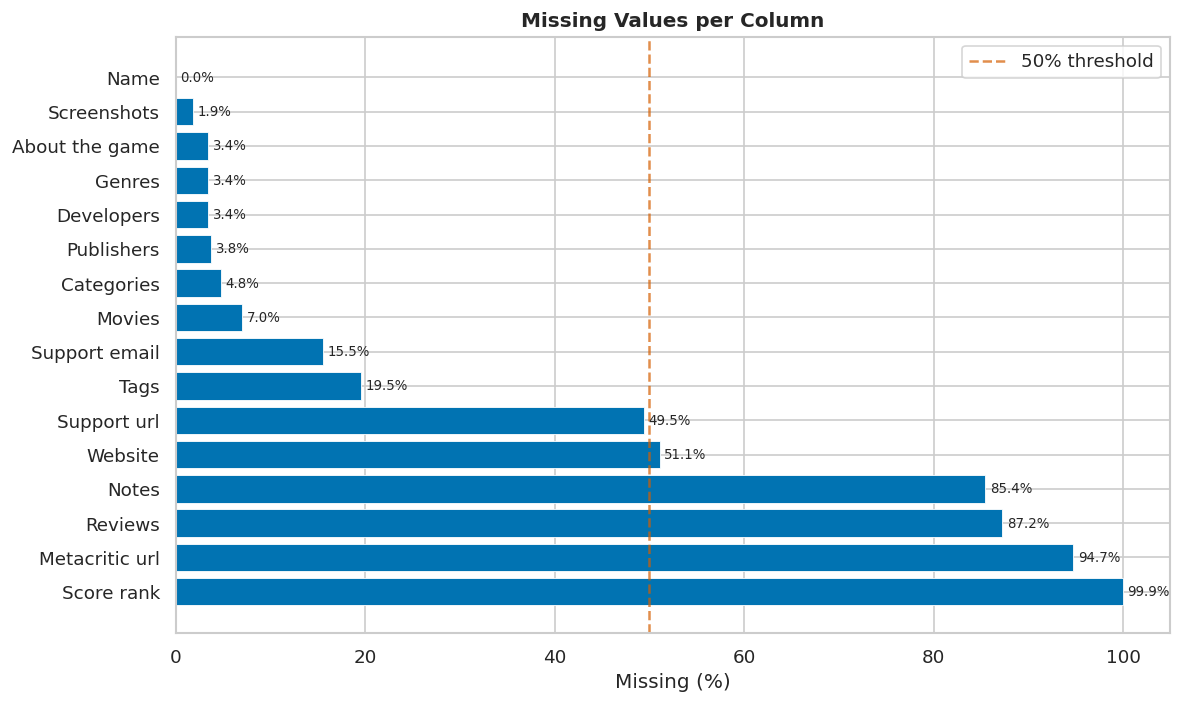

In [5]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df  = missing_df[missing_df['count'] > 0].sort_values('count', ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_df.index, missing_df['pct'],
               color=C1, edgecolor='white', linewidth=0.5)
for bar, pct in zip(bars, missing_df['pct']):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=8)
ax.axvline(50, color=C4, linestyle='--', alpha=0.7, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Column', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Target Variables

Games with >= 10 reviews: 39449
Games with 0 reviews: 14051

Reception class distribution:
reception
Positive    26804
Mixed       10376
Negative     2250
Name: count, dtype: int64

Reception class %:
reception
Positive    67.98
Mixed       26.31
Negative     5.71
Name: count, dtype: float64


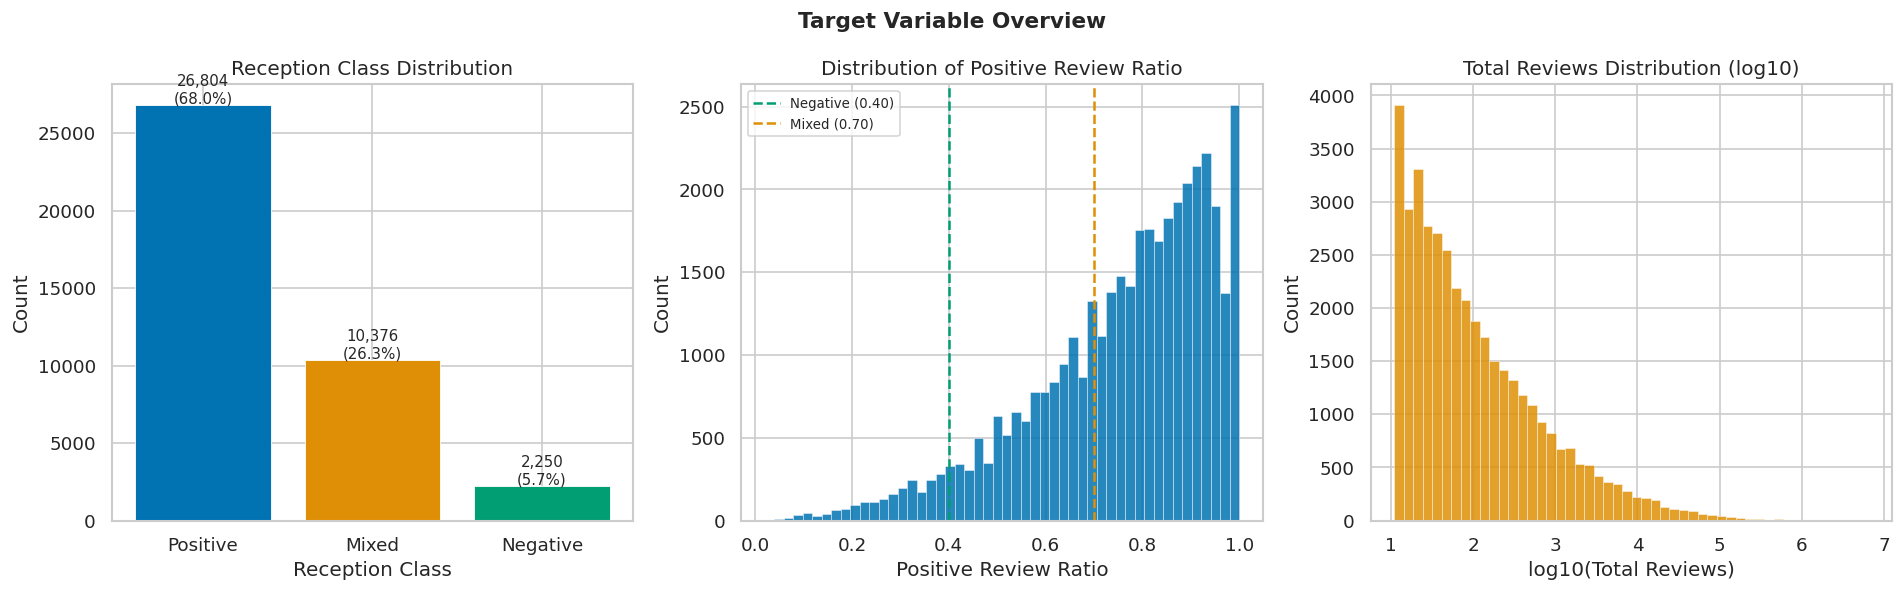

In [6]:
df['total_reviews']  = df['Positive'] + df['Negative']
df['positive_ratio'] = df['Positive'] / df['total_reviews'].replace(0, np.nan)

print('Games with >= 10 reviews:', (df['total_reviews'] >= 10).sum())
print('Games with 0 reviews:',     (df['total_reviews'] == 0).sum())

df_model = df[df['total_reviews'] >= 10].copy()

df_model['reception'] = pd.cut(
    df_model['positive_ratio'],
    bins=[0, 0.40, 0.70, 1.001],
    labels=['Negative', 'Mixed', 'Positive']
)

df_model = df_model.dropna(subset=['reception'])

print('\nReception class distribution:')
print(df_model['reception'].value_counts())
print('\nReception class %:')
print((df_model['reception'].value_counts() / len(df_model) * 100).round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Target Variable Overview', fontsize=13, fontweight='bold')

reception_counts = df_model['reception'].value_counts()
axes[0].bar(reception_counts.index, reception_counts.values,
            color=[colors[c] for c in reception_counts.index],
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Reception Class Distribution')
axes[0].set_xlabel('Reception Class')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(reception_counts.items()):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df_model)*100:.1f}%)',
                 ha='center', fontsize=9)

axes[1].hist(df_model['positive_ratio'].dropna(), bins=50,
             color=C1, edgecolor='white', linewidth=0.3, alpha=0.85)
axes[1].axvline(0.40, color=C_NEGATIVE, linestyle='--', linewidth=1.5, label='Negative (0.40)')
axes[1].axvline(0.70, color=C_MIXED,    linestyle='--', linewidth=1.5, label='Mixed (0.70)')
axes[1].set_title('Distribution of Positive Review Ratio')
axes[1].set_xlabel('Positive Review Ratio')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

axes[2].hist(np.log10(df_model['total_reviews'] + 1), bins=50,
             color=C2, edgecolor='white', linewidth=0.3, alpha=0.85)
axes[2].set_title('Total Reviews Distribution (log10)')
axes[2].set_xlabel('log10(Total Reviews)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 2.4 Interesting Findings

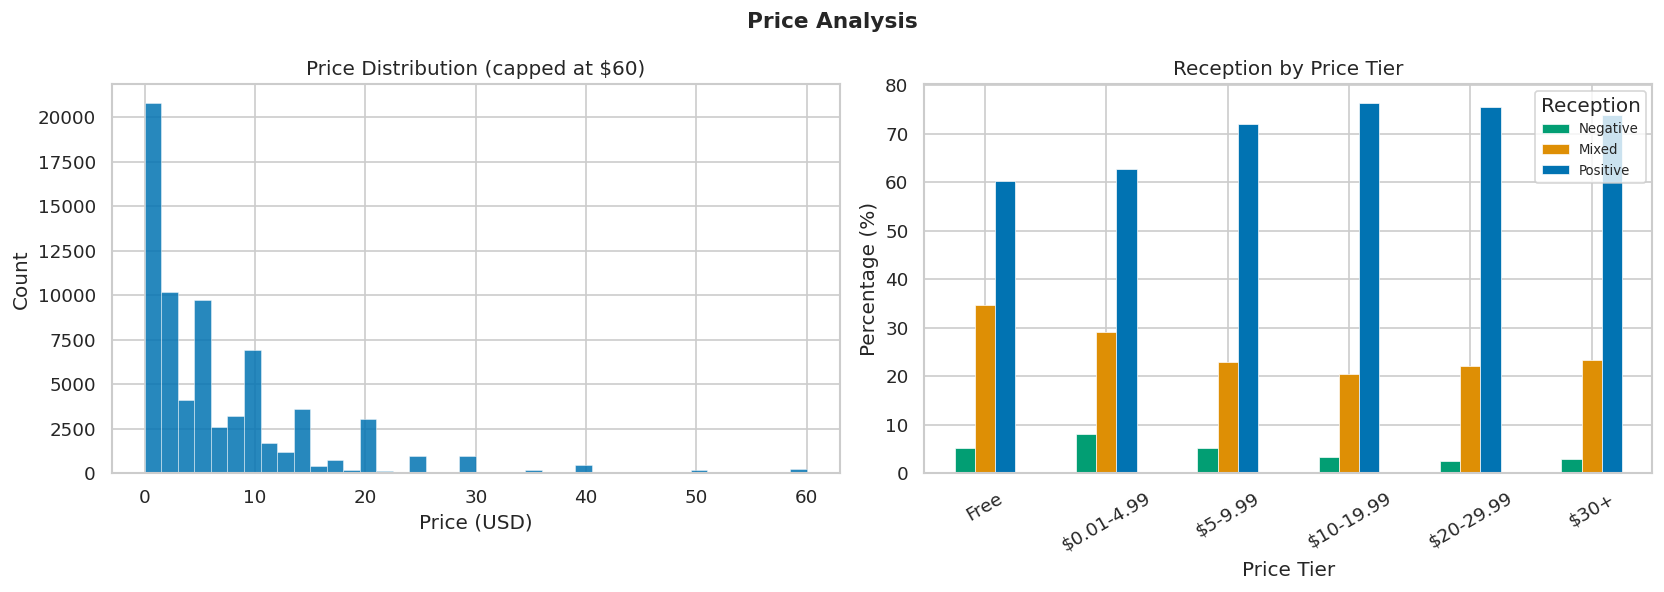

In [7]:
# Price analysis
df_model['price_bucket'] = pd.cut(df_model['Price'],
    bins=[-0.01, 0, 4.99, 9.99, 19.99, 29.99, 999],
    labels=['Free', '$0.01-4.99', '$5-9.99', '$10-19.99', '$20-29.99', '$30+'])

price_reception     = df_model.groupby(['price_bucket', 'reception'], observed=True).size().unstack(fill_value=0)
price_reception_pct = price_reception.div(price_reception.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Analysis', fontsize=13, fontweight='bold')

price_capped = df[df['Price'] <= 60]['Price']
axes[0].hist(price_capped, bins=40, color=C1, edgecolor='white', linewidth=0.3, alpha=0.85)
axes[0].set_title('Price Distribution (capped at $60)')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

price_reception_pct[['Negative', 'Mixed', 'Positive']].plot(
    kind='bar', ax=axes[1],
    color=[C_NEGATIVE, C_MIXED, C_POSITIVE],
    edgecolor='white', linewidth=0.4)
axes[1].set_title('Reception by Price Tier')
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Reception', fontsize=8)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

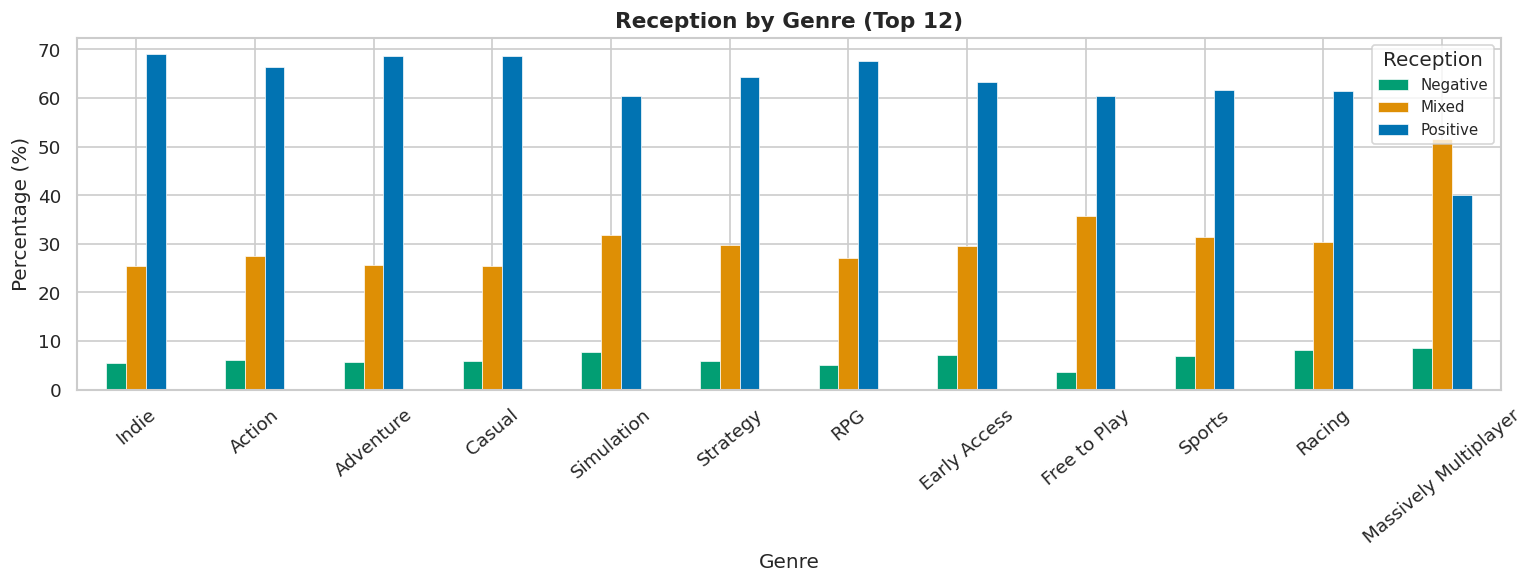

In [8]:
# Genre analysis
df_genres               = df_model.copy()
df_genres['genre_list'] = df_genres['Genres'].fillna('').str.split(',')
df_genres_exp           = df_genres.explode('genre_list')
df_genres_exp['genre_list'] = df_genres_exp['genre_list'].str.strip()
df_genres_exp           = df_genres_exp[df_genres_exp['genre_list'] != '']

top_genres       = df_genres_exp['genre_list'].value_counts().head(12).index
df_top           = df_genres_exp[df_genres_exp['genre_list'].isin(top_genres)]
genre_reception  = df_top.groupby(['genre_list', 'reception'], observed=True).size().unstack(fill_value=0)
genre_reception_pct = genre_reception.div(genre_reception.sum(axis=1), axis=0) * 100
genre_reception_pct = genre_reception_pct.loc[
    df_genres_exp[df_genres_exp['genre_list'].isin(top_genres)]['genre_list']
    .value_counts().index
]

fig, ax = plt.subplots(figsize=(13, 5))
genre_reception_pct[['Negative', 'Mixed', 'Positive']].plot(
    kind='bar', ax=ax,
    color=[C_NEGATIVE, C_MIXED, C_POSITIVE],
    edgecolor='white', linewidth=0.4)
ax.set_title('Reception by Genre (Top 12)', fontsize=13, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Reception', fontsize=9)
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

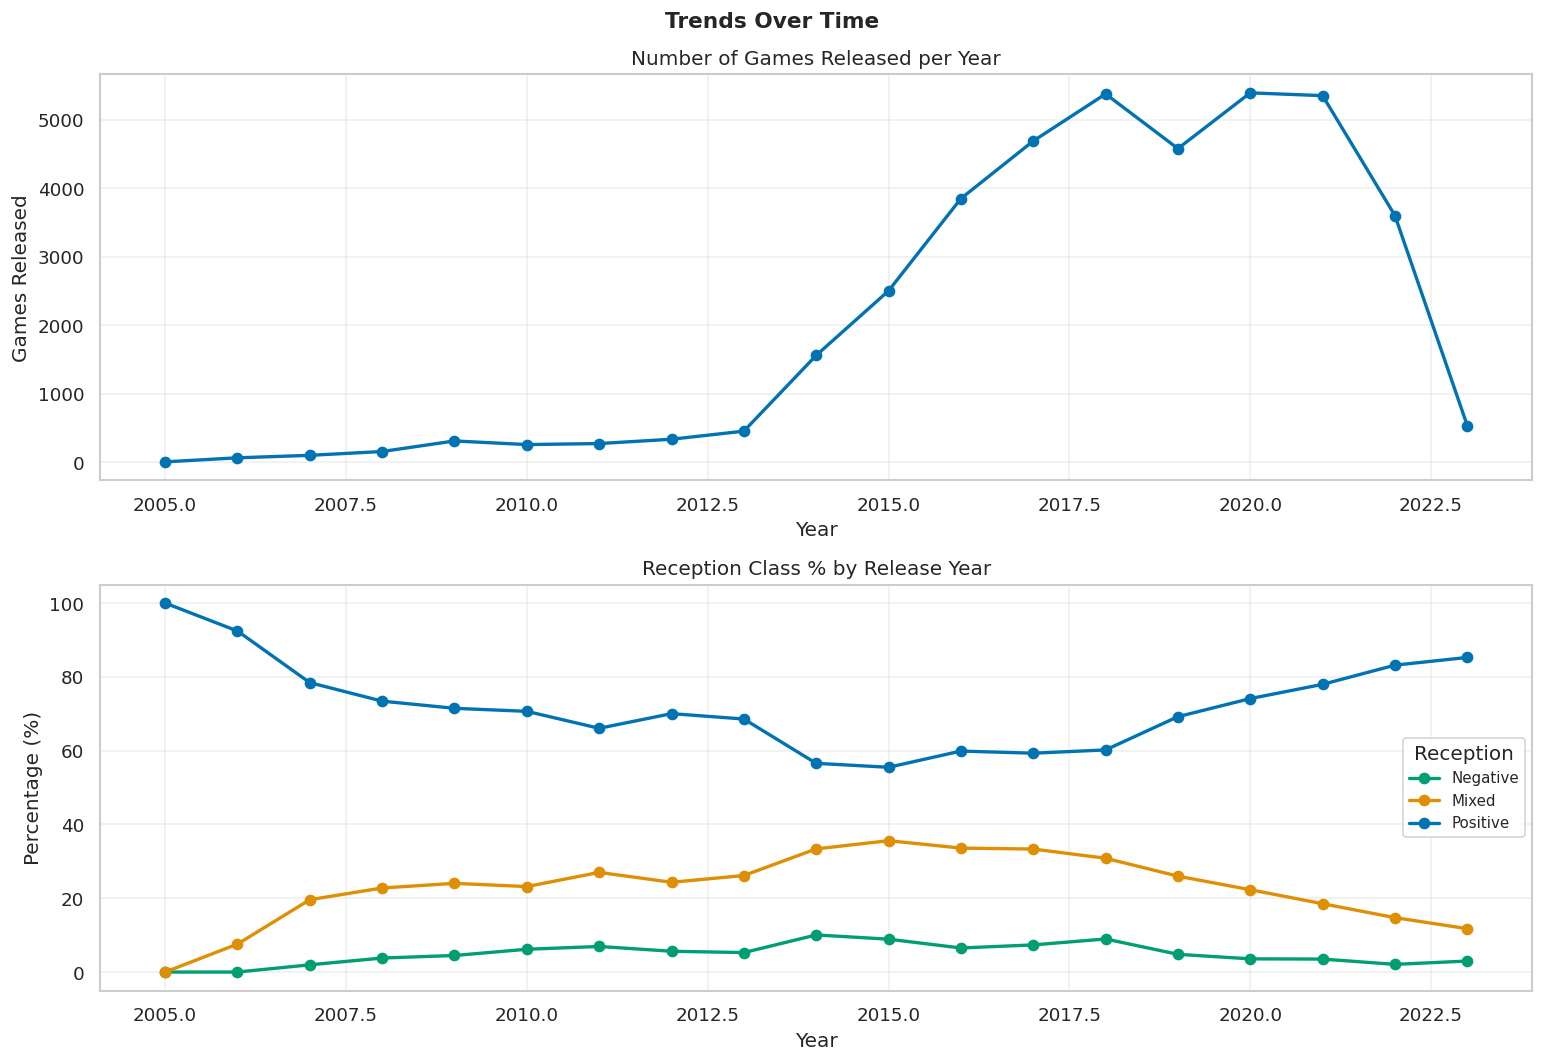

In [9]:
# Release year trends
df_model['release_date_parsed'] = pd.to_datetime(df_model['Release date'], format='mixed', errors='coerce')
df_model['release_year']        = df_model['release_date_parsed'].dt.year
df_model['release_month']       = df_model['release_date_parsed'].dt.month

df_year              = df_model[(df_model['release_year'] >= 2005) & (df_model['release_year'] <= 2024)].copy()
year_reception       = df_year.groupby(['release_year', 'reception'], observed=True).size().unstack(fill_value=0)
year_reception_pct   = year_reception.div(year_reception.sum(axis=1), axis=0) * 100
year_counts          = df_year.groupby('release_year').size()

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('Trends Over Time', fontsize=13, fontweight='bold')

year_counts.plot(ax=axes[0], color=C1, marker='o', linewidth=2)
axes[0].set_title('Number of Games Released per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Games Released')
axes[0].grid(alpha=0.3)

year_reception_pct[['Negative', 'Mixed', 'Positive']].plot(
    ax=axes[1],
    color=[C_NEGATIVE, C_MIXED, C_POSITIVE],
    marker='o', linewidth=2)
axes[1].set_title('Reception Class % by Release Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Reception', fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

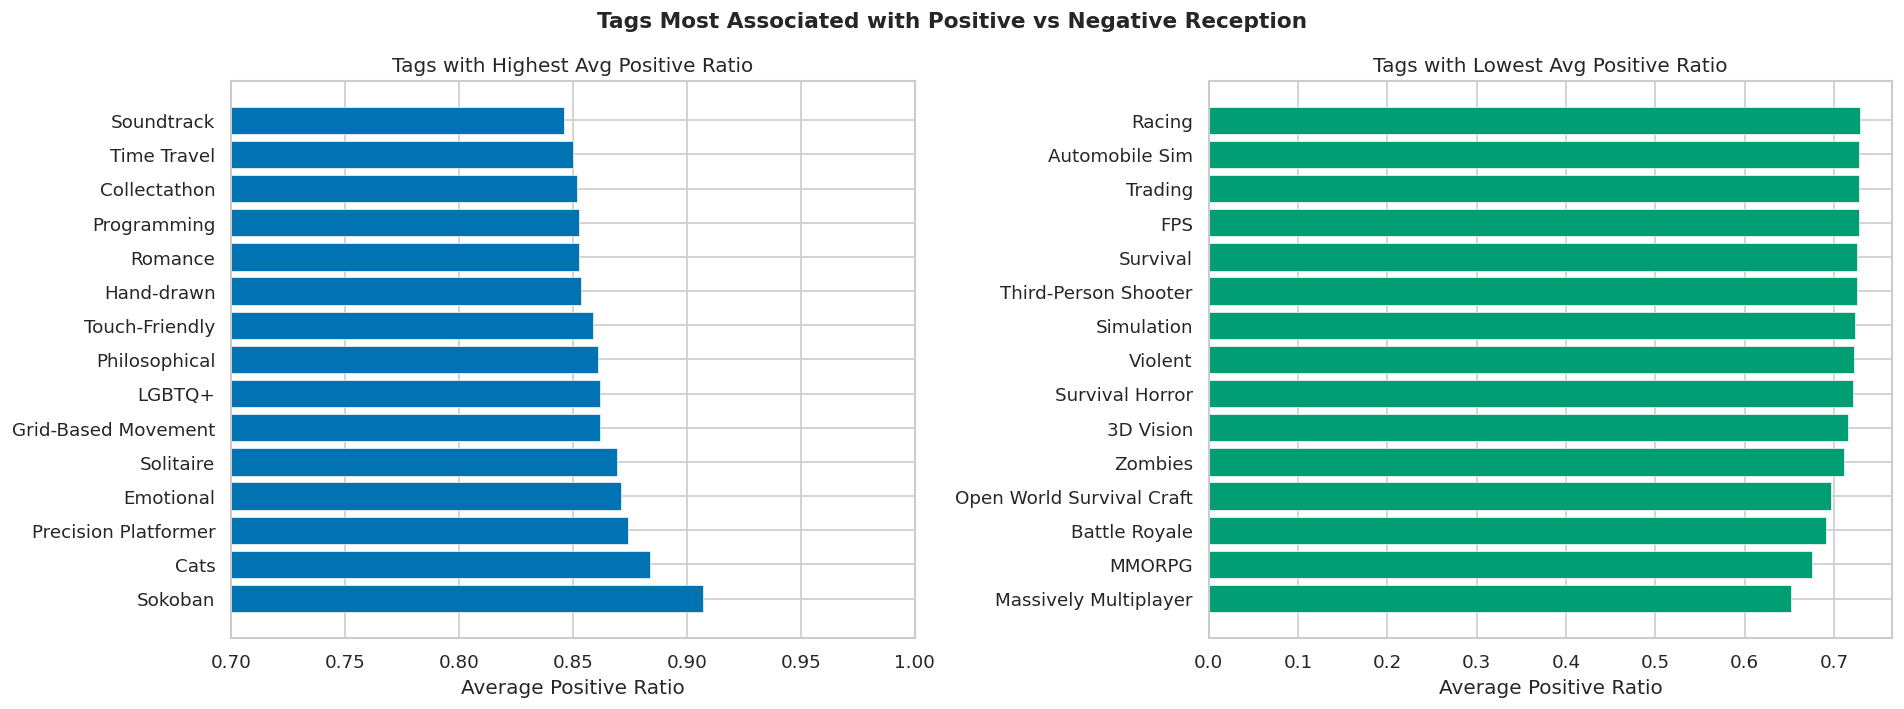

In [10]:
# Tag analysis
df_tags               = df_model.copy()
df_tags['tag_list']   = df_tags['Tags'].fillna('').str.split(',')
df_tags_exp           = df_tags.explode('tag_list')
df_tags_exp['tag_list'] = df_tags_exp['tag_list'].str.strip()
df_tags_exp           = df_tags_exp[df_tags_exp['tag_list'] != '']

tag_stats = df_tags_exp.groupby('tag_list').agg(
    count=('reception', 'count'),
    pos_rate=('positive_ratio', 'mean')
).reset_index()
tag_stats     = tag_stats[tag_stats['count'] >= 200]
top_pos_tags  = tag_stats.nlargest(15, 'pos_rate')
top_neg_tags  = tag_stats.nsmallest(15, 'pos_rate')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tags Most Associated with Positive vs Negative Reception',
             fontsize=13, fontweight='bold')

axes[0].barh(top_pos_tags['tag_list'], top_pos_tags['pos_rate'],
             color=C_POSITIVE, edgecolor='white', linewidth=0.4)
axes[0].set_title('Tags with Highest Avg Positive Ratio')
axes[0].set_xlabel('Average Positive Ratio')
axes[0].set_xlim(0.7, 1.0)

axes[1].barh(top_neg_tags['tag_list'], top_neg_tags['pos_rate'],
             color=C_NEGATIVE, edgecolor='white', linewidth=0.4)
axes[1].set_title('Tags with Lowest Avg Positive Ratio')
axes[1].set_xlabel('Average Positive Ratio')

plt.tight_layout()
plt.show()

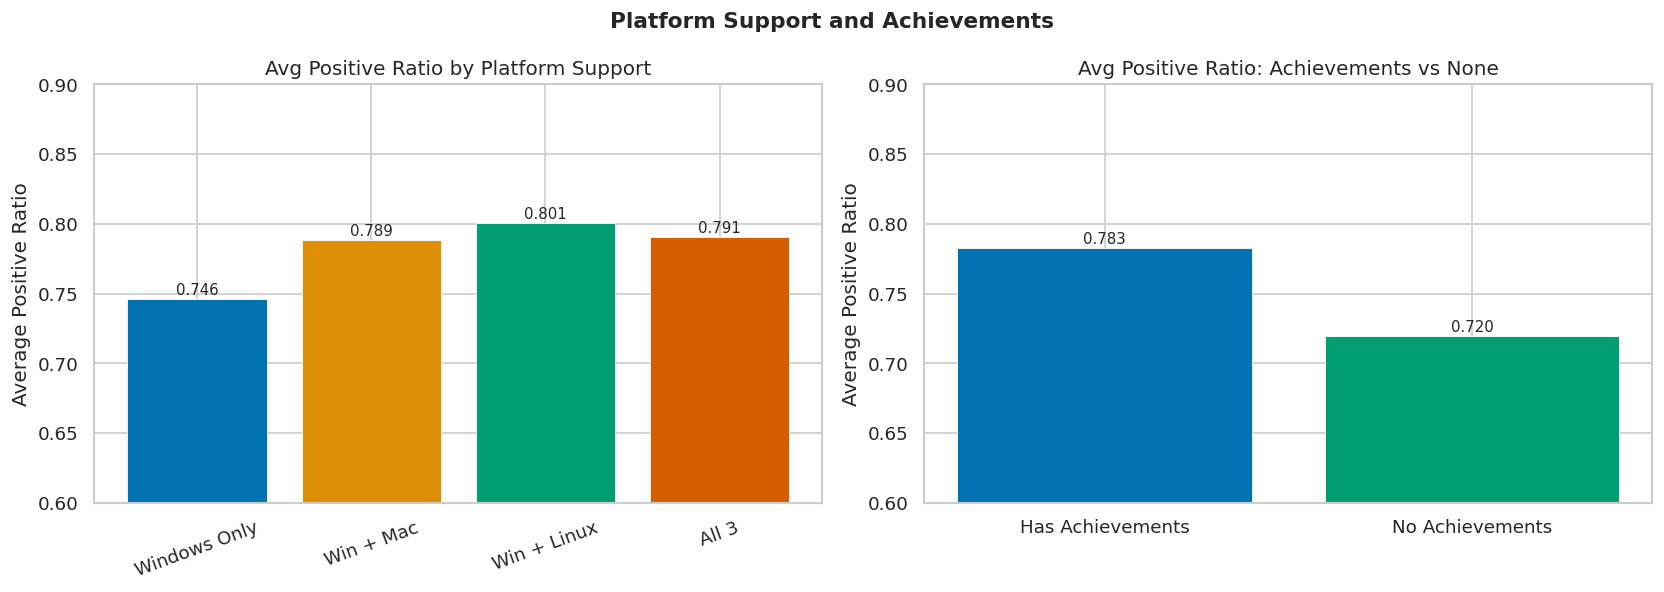

In [11]:
# Platform and achievements
platform_data = {
    'Windows Only': df_model[(df_model['Windows'])  & (~df_model['Mac']) & (~df_model['Linux'])]['positive_ratio'].mean(),
    'Win + Mac':    df_model[(df_model['Windows'])  & (df_model['Mac'])  & (~df_model['Linux'])]['positive_ratio'].mean(),
    'Win + Linux':  df_model[(df_model['Windows'])  & (~df_model['Mac']) & (df_model['Linux']) ]['positive_ratio'].mean(),
    'All 3':        df_model[(df_model['Windows'])  & (df_model['Mac'])  & (df_model['Linux']) ]['positive_ratio'].mean(),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Platform Support and Achievements', fontsize=13, fontweight='bold')

axes[0].bar(platform_data.keys(), platform_data.values(),
            color=PALETTE[:4], edgecolor='white', linewidth=0.5)
axes[0].set_title('Avg Positive Ratio by Platform Support')
axes[0].set_ylabel('Average Positive Ratio')
axes[0].set_ylim(0.6, 0.9)
axes[0].tick_params(axis='x', rotation=20)
for i, (k, v) in enumerate(platform_data.items()):
    axes[0].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)

has_ach = df_model[df_model['Achievements'] > 0]['positive_ratio'].mean()
no_ach  = df_model[df_model['Achievements'] == 0]['positive_ratio'].mean()
axes[1].bar(['Has Achievements', 'No Achievements'], [has_ach, no_ach],
            color=[C_POSITIVE, C_NEGATIVE], edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg Positive Ratio: Achievements vs None')
axes[1].set_ylabel('Average Positive Ratio')
axes[1].set_ylim(0.6, 0.9)
for i, v in enumerate([has_ach, no_ach]):
    axes[1].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

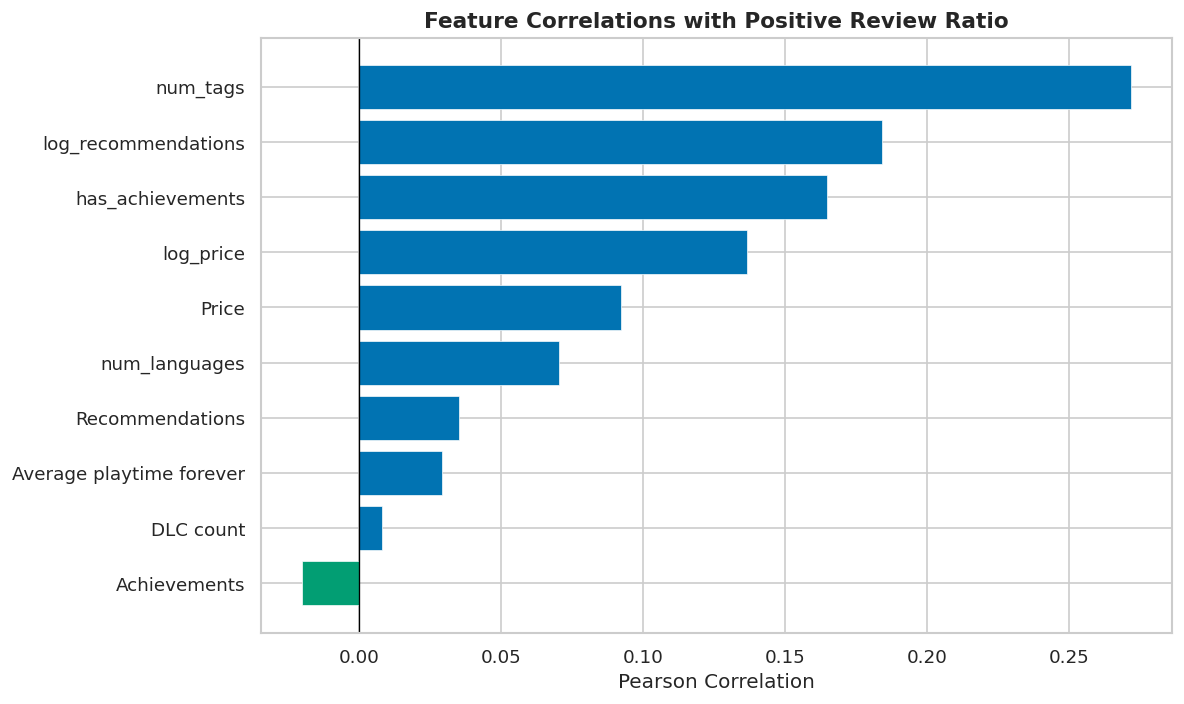

In [12]:
# Correlations with positive ratio
df_corr = df_model.copy()
df_corr['num_languages']       = df_corr['Supported languages'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df_corr['num_tags']            = df_corr['Tags'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df_corr['has_achievements']    = (df_corr['Achievements'] > 0).astype(int)
df_corr['log_price']           = np.log1p(df_corr['Price'])
df_corr['log_recommendations'] = np.log1p(df_corr['Recommendations'])

corr_features = ['Price', 'DLC count', 'Achievements', 'Recommendations',
                 'Average playtime forever', 'num_languages', 'num_tags',
                 'has_achievements', 'log_price', 'log_recommendations']
corrs = df_corr[corr_features + ['positive_ratio']].corr()['positive_ratio'].drop('positive_ratio').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [C_NEGATIVE if c < 0 else C_POSITIVE for c in corrs.values]
ax.barh(corrs.index, corrs.values, color=bar_colors, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlations with Positive Review Ratio',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering & Preprocessing

In [13]:
def build_features(df_input):
    df = df_input.copy()

    df['release_date_parsed'] = pd.to_datetime(df['Release date'], format='mixed', errors='coerce')
    df['release_year']        = df['release_date_parsed'].dt.year.fillna(0).astype(int)
    df['release_month']       = df['release_date_parsed'].dt.month.fillna(0).astype(int)

    df['num_languages']    = df['Supported languages'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
    df['num_tags']         = df['Tags'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
    df['num_screenshots']  = df['Screenshots'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
    df['has_movie']        = df['Movies'].notna().astype(int)
    df['has_website']      = df['Website'].notna().astype(int)
    df['has_achievements'] = (df['Achievements'] > 0).astype(int)
    df['log_price']        = np.log1p(df['Price'])
    df['is_free']          = (df['Price'] == 0).astype(int)
    df['mac']              = df['Mac'].astype(int)
    df['linux']            = df['Linux'].astype(int)

    top_genre_list = ['Indie', 'Action', 'Casual', 'Adventure', 'Simulation',
                      'Strategy', 'RPG', 'Early Access', 'Free to Play', 'Sports']
    for genre in top_genre_list:
        col = 'genre_' + genre.lower().replace(' ', '_')
        df[col] = df['Genres'].fillna('').apply(lambda x, g=genre: 1 if g in x else 0)

    top_cat_list = ['Single-player', 'Multi-player', 'Co-op',
                    'Steam Achievements', 'Full controller support']
    for cat in top_cat_list:
        col = 'cat_' + cat.lower().replace('-', '_').replace(' ', '_')
        df[col] = df['Categories'].fillna('').apply(lambda x, c=cat: 1 if c in x else 0)

    basic_feature_cols = [
        'log_price', 'is_free', 'DLC count', 'Achievements', 'has_achievements',
        'num_languages', 'num_screenshots', 'has_movie', 'has_website',
        'Required age', 'mac', 'linux', 'release_year', 'release_month', 'num_tags',
        'genre_indie', 'genre_action', 'genre_casual', 'genre_adventure',
        'genre_simulation', 'genre_strategy', 'genre_rpg', 'genre_early_access',
        'genre_free_to_play', 'genre_sports',
        'cat_single_player', 'cat_multi_player', 'cat_co_op',
        'cat_steam_achievements', 'cat_full_controller_support'
    ]

    X_basic      = df[basic_feature_cols].fillna(0)
    X_tags_text  = df['Tags'].fillna('')
    y            = df['reception']

    return X_basic, X_tags_text, y, basic_feature_cols


X_basic, X_tags_text, y, feature_cols = build_features(df_model)
print('Basic feature matrix shape:', X_basic.shape)
print('Feature columns:', feature_cols)

Basic feature matrix shape: (39430, 30)
Feature columns: ['log_price', 'is_free', 'DLC count', 'Achievements', 'has_achievements', 'num_languages', 'num_screenshots', 'has_movie', 'has_website', 'Required age', 'mac', 'linux', 'release_year', 'release_month', 'num_tags', 'genre_indie', 'genre_action', 'genre_casual', 'genre_adventure', 'genre_simulation', 'genre_strategy', 'genre_rpg', 'genre_early_access', 'genre_free_to_play', 'genre_sports', 'cat_single_player', 'cat_multi_player', 'cat_co_op', 'cat_steam_achievements', 'cat_full_controller_support']


In [14]:
# Train/test split
X_train_basic, X_test_basic, X_train_tags, X_test_tags, y_train, y_test = train_test_split(
    X_basic, X_tags_text, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train size:', len(y_train))
print('Test size: ', len(y_test))
print('\nTrain class distribution:')
print(y_train.value_counts())
print('\nTest class distribution:')
print(y_test.value_counts())

classes          = np.array(['Negative', 'Mixed', 'Positive'])
class_weights    = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print('\nClass weights:', class_weight_dict)

Train size: 31544
Test size:  7886

Train class distribution:
reception
Positive    21443
Mixed        8301
Negative     1800
Name: count, dtype: int64

Test class distribution:
reception
Positive    5361
Mixed       2075
Negative     450
Name: count, dtype: int64

Class weights: {'Negative': 5.841481481481481, 'Mixed': 1.266674697827571, 'Positive': 0.4903542725675823}


In [15]:
# Build TF-IDF tag features
X_train_tags_clean = X_train_tags.str.replace(',', ' ')
X_test_tags_clean  = X_test_tags.str.replace(',', ' ')

tfidf = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 1),
    sublinear_tf=True
)

X_train_tfidf    = tfidf.fit_transform(X_train_tags_clean)
X_test_tfidf     = tfidf.transform(X_test_tags_clean)

X_train_combined = hstack([csr_matrix(X_train_basic.values), X_train_tfidf])
X_test_combined  = hstack([csr_matrix(X_test_basic.values),  X_test_tfidf])

print('TF-IDF shape (train):    ', X_train_tfidf.shape)
print('Combined shape (train):  ', X_train_combined.shape)

TF-IDF shape (train):     (31544, 300)
Combined shape (train):   (31544, 330)


---
## 4. Baseline Models

In [16]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred      = model.predict(X_test)
    acc         = accuracy_score(y_test, y_pred)
    macro_f1    = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    print(f'\n=== {model_name} ===')
    print(f'Accuracy:     {acc:.4f}')
    print(f'Macro F1:     {macro_f1:.4f}')
    print(f'Weighted F1:  {weighted_f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred))

    fig, ax = plt.subplots(figsize=(6, 5))
    cm   = confusion_matrix(y_test, y_pred, labels=['Negative', 'Mixed', 'Positive'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Mixed', 'Positive'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix: {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'model':       model_name,
        'accuracy':    round(acc, 4),
        'macro_f1':    round(macro_f1, 4),
        'weighted_f1': round(weighted_f1, 4),
        'y_pred':      y_pred
    }

results = []

### 4.1 Baseline 1: Logistic Regression (Basic Features)


=== Logistic Regression (Basic Features) ===
Accuracy:     0.5129
Macro F1:     0.3855
Weighted F1:  0.5544

Classification Report:
              precision    recall  f1-score   support

       Mixed       0.34      0.23      0.27      2075
    Negative       0.11      0.58      0.19       450
    Positive       0.79      0.62      0.69      5361

    accuracy                           0.51      7886
   macro avg       0.41      0.47      0.39      7886
weighted avg       0.63      0.51      0.55      7886



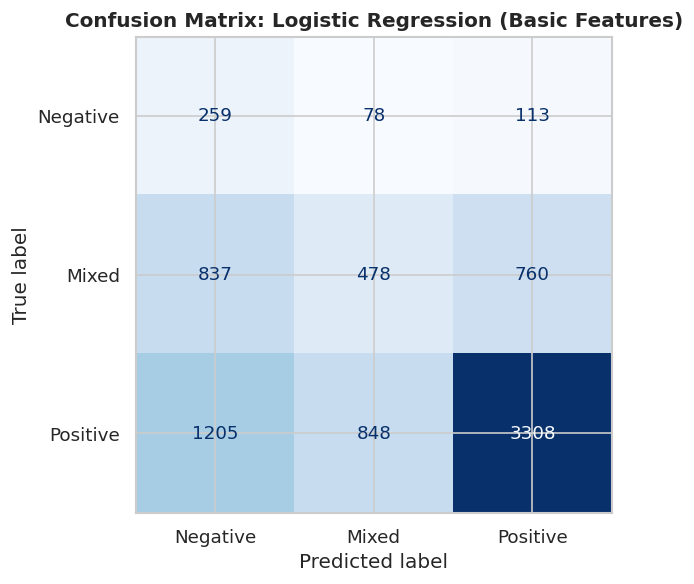

In [17]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    C=1.0
)
lr_baseline.fit(X_train_basic, y_train)
res = evaluate_model(lr_baseline, X_test_basic, y_test, 'Logistic Regression (Basic Features)')
results.append(res)

### 4.2 Baseline 2: Decision Tree (Basic Features)


=== Decision Tree (Basic Features) ===
Accuracy:     0.5056
Macro F1:     0.4040
Weighted F1:  0.5530

Classification Report:
              precision    recall  f1-score   support

       Mixed       0.34      0.39      0.36      2075
    Negative       0.12      0.49      0.19       450
    Positive       0.81      0.55      0.66      5361

    accuracy                           0.51      7886
   macro avg       0.42      0.48      0.40      7886
weighted avg       0.65      0.51      0.55      7886



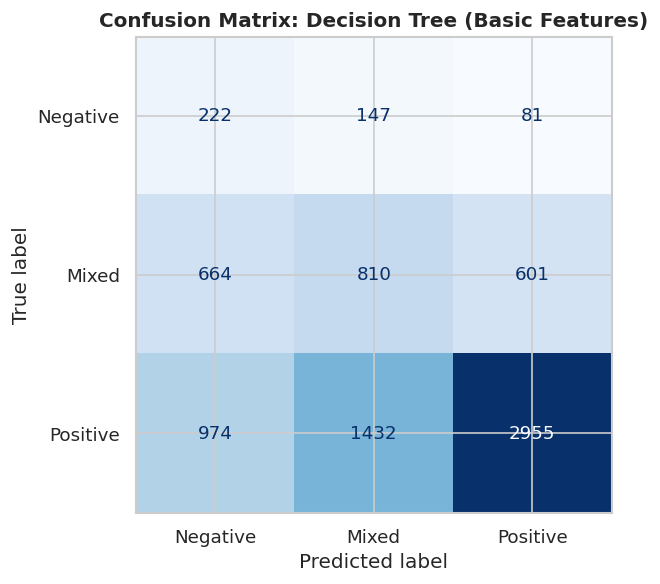

In [18]:
dt_baseline = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt_baseline.fit(X_train_basic, y_train)
res = evaluate_model(dt_baseline, X_test_basic, y_test, 'Decision Tree (Basic Features)')
results.append(res)

---
## 5. Final Models

### 5.1 Random Forest (Basic Features)


=== Random Forest (Basic Features) ===
Accuracy:     0.6977
Macro F1:     0.4322
Weighted F1:  0.6518

Classification Report:
              precision    recall  f1-score   support

       Mixed       0.51      0.24      0.33      2075
    Negative       0.28      0.10      0.15       450
    Positive       0.74      0.92      0.82      5361

    accuracy                           0.70      7886
   macro avg       0.51      0.42      0.43      7886
weighted avg       0.65      0.70      0.65      7886



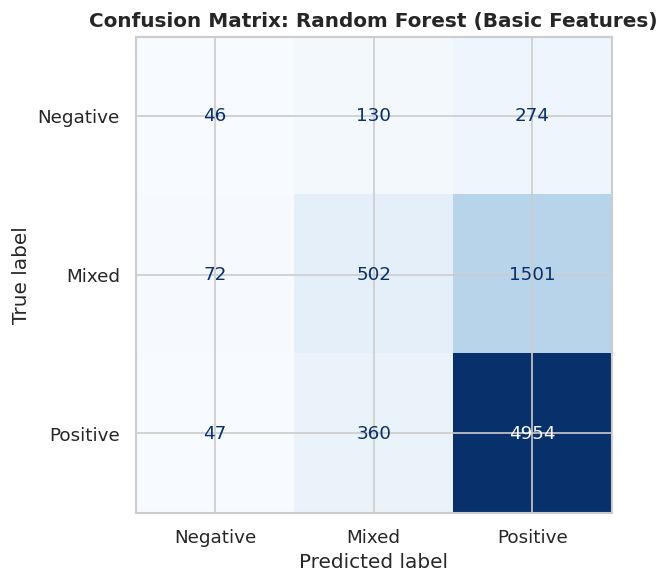

In [19]:
rf_basic = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_basic.fit(X_train_basic, y_train)
res = evaluate_model(rf_basic, X_test_basic, y_test, 'Random Forest (Basic Features)')
results.append(res)

### 5.2 Random Forest (Basic + TF-IDF Tags) -- Novel Contribution


=== Random Forest (Basic + TF-IDF Tags) ===
Accuracy:     0.6647
Macro F1:     0.4765
Weighted F1:  0.6623

Classification Report:
              precision    recall  f1-score   support

       Mixed       0.45      0.38      0.41      2075
    Negative       0.19      0.26      0.22       450
    Positive       0.78      0.81      0.80      5361

    accuracy                           0.66      7886
   macro avg       0.48      0.48      0.48      7886
weighted avg       0.66      0.66      0.66      7886



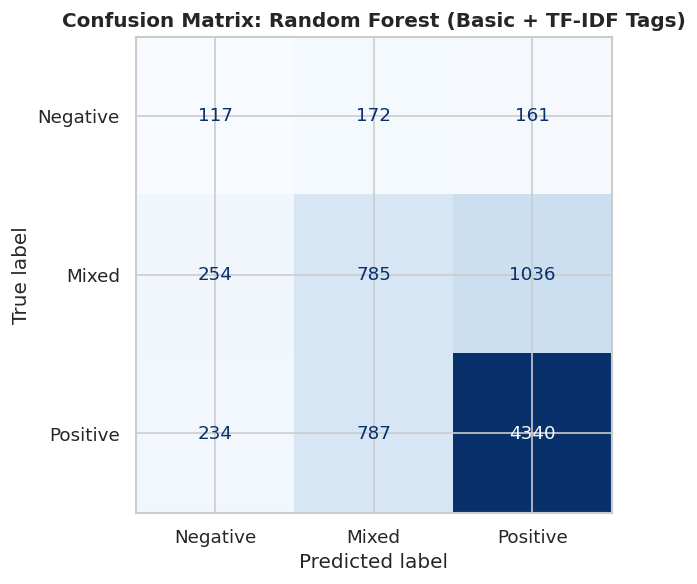

In [20]:
rf_combined = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_combined.fit(X_train_combined, y_train)
res = evaluate_model(rf_combined, X_test_combined, y_test,
                     'Random Forest (Basic + TF-IDF Tags)')
results.append(res)

### 5.3 Logistic Regression (Basic + TF-IDF Tags)


=== Logistic Regression (Basic + TF-IDF Tags) ===
Accuracy:     0.5175
Macro F1:     0.3897
Weighted F1:  0.5576

Classification Report:
              precision    recall  f1-score   support

       Mixed       0.34      0.23      0.28      2075
    Negative       0.12      0.59      0.20       450
    Positive       0.79      0.62      0.70      5361

    accuracy                           0.52      7886
   macro avg       0.42      0.48      0.39      7886
weighted avg       0.64      0.52      0.56      7886



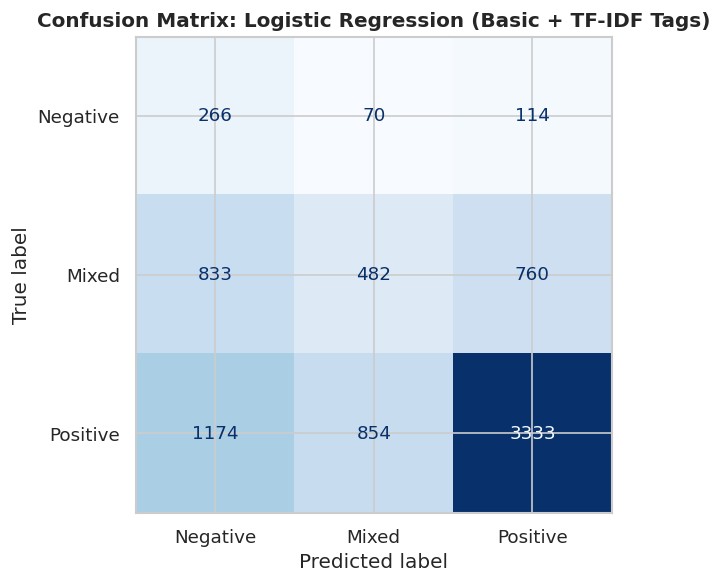

In [21]:
lr_combined = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    C=1.0
)
lr_combined.fit(X_train_combined, y_train)
res = evaluate_model(lr_combined, X_test_combined, y_test,
                     'Logistic Regression (Basic + TF-IDF Tags)')
results.append(res)

---
## 6. Results Comparison

                                    Model  Accuracy  Macro F1  Weighted F1
     Logistic Regression (Basic Features)    0.5129    0.3855       0.5544
           Decision Tree (Basic Features)    0.5056    0.4040       0.5530
           Random Forest (Basic Features)    0.6977    0.4322       0.6518
      Random Forest (Basic + TF-IDF Tags)    0.6647    0.4765       0.6623
Logistic Regression (Basic + TF-IDF Tags)    0.5175    0.3897       0.5576


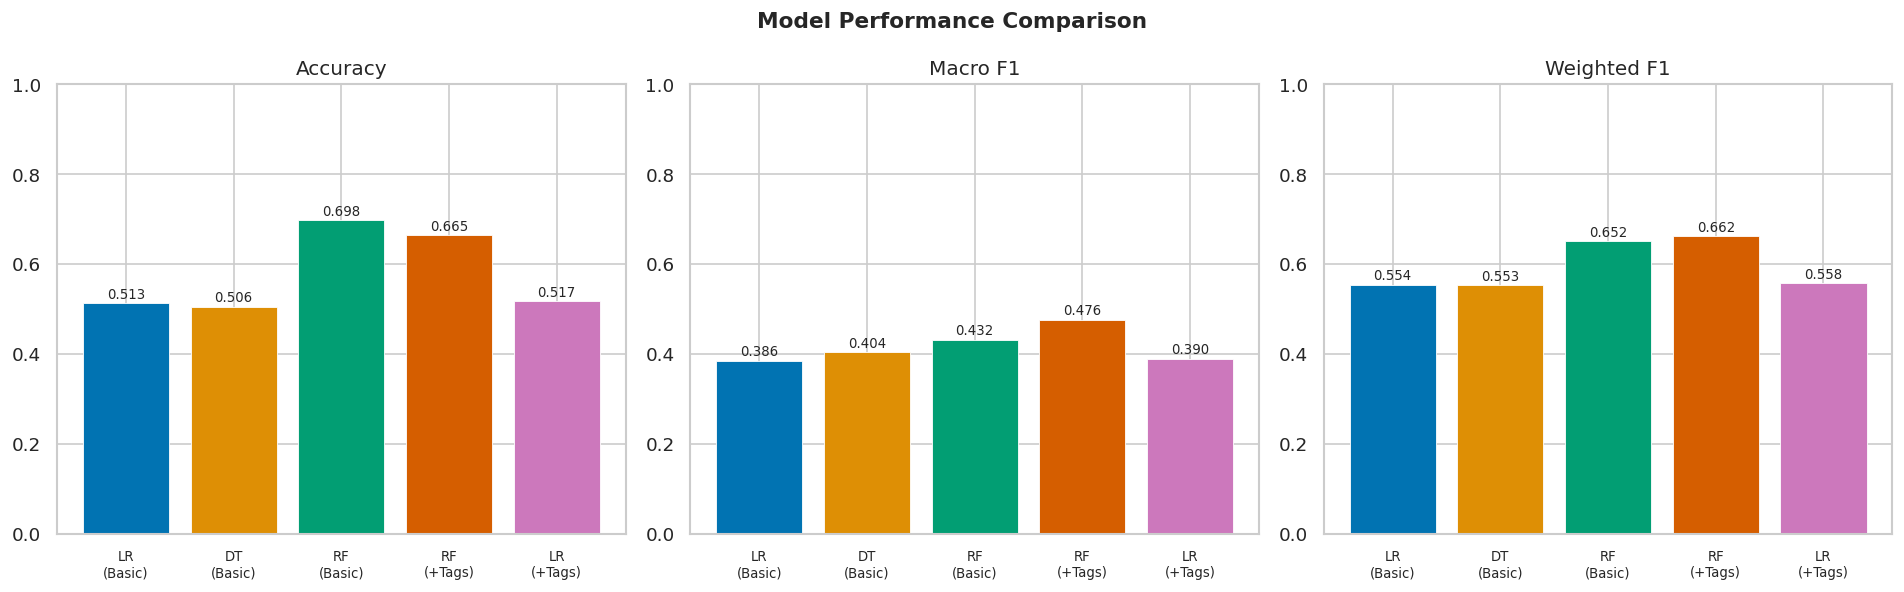

In [22]:
results_df = pd.DataFrame([{
    'Model':       r['model'],
    'Accuracy':    r['accuracy'],
    'Macro F1':    r['macro_f1'],
    'Weighted F1': r['weighted_f1']
} for r in results])

print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

metrics      = ['Accuracy', 'Macro F1', 'Weighted F1']
model_labels = ['LR\n(Basic)', 'DT\n(Basic)', 'RF\n(Basic)', 'RF\n(+Tags)', 'LR\n(+Tags)']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(range(len(results_df)), results_df[metric],
                       color=PALETTE[:len(results_df)],
                       edgecolor='white', linewidth=0.5)
    axes[i].set_title(metric)
    axes[i].set_xticks(range(len(results_df)))
    axes[i].set_xticklabels(model_labels[:len(results_df)], fontsize=8)
    axes[i].set_ylim(0, 1.0)
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                     f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

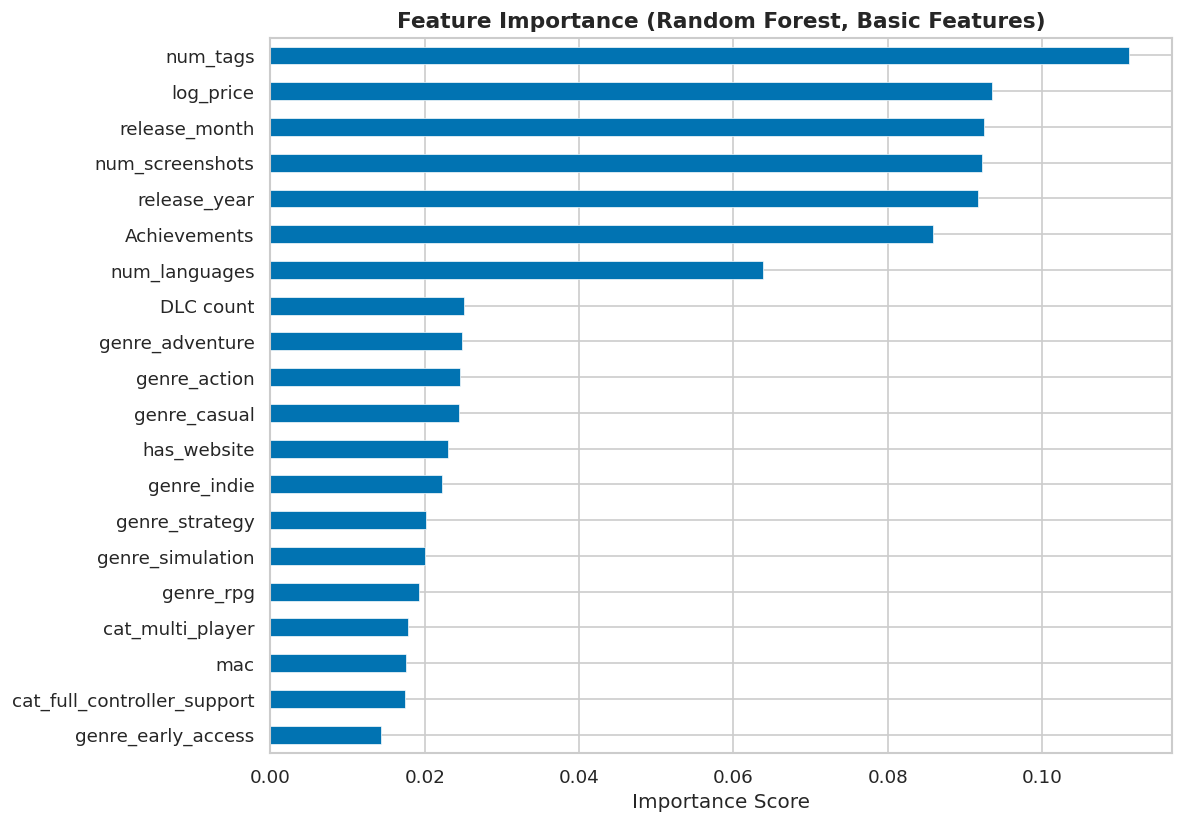

In [23]:
# Feature importance from Random Forest (Basic Features)
importances = pd.Series(rf_basic.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color=C1, edgecolor='white', linewidth=0.4)
ax.set_title('Feature Importance (Random Forest, Basic Features)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

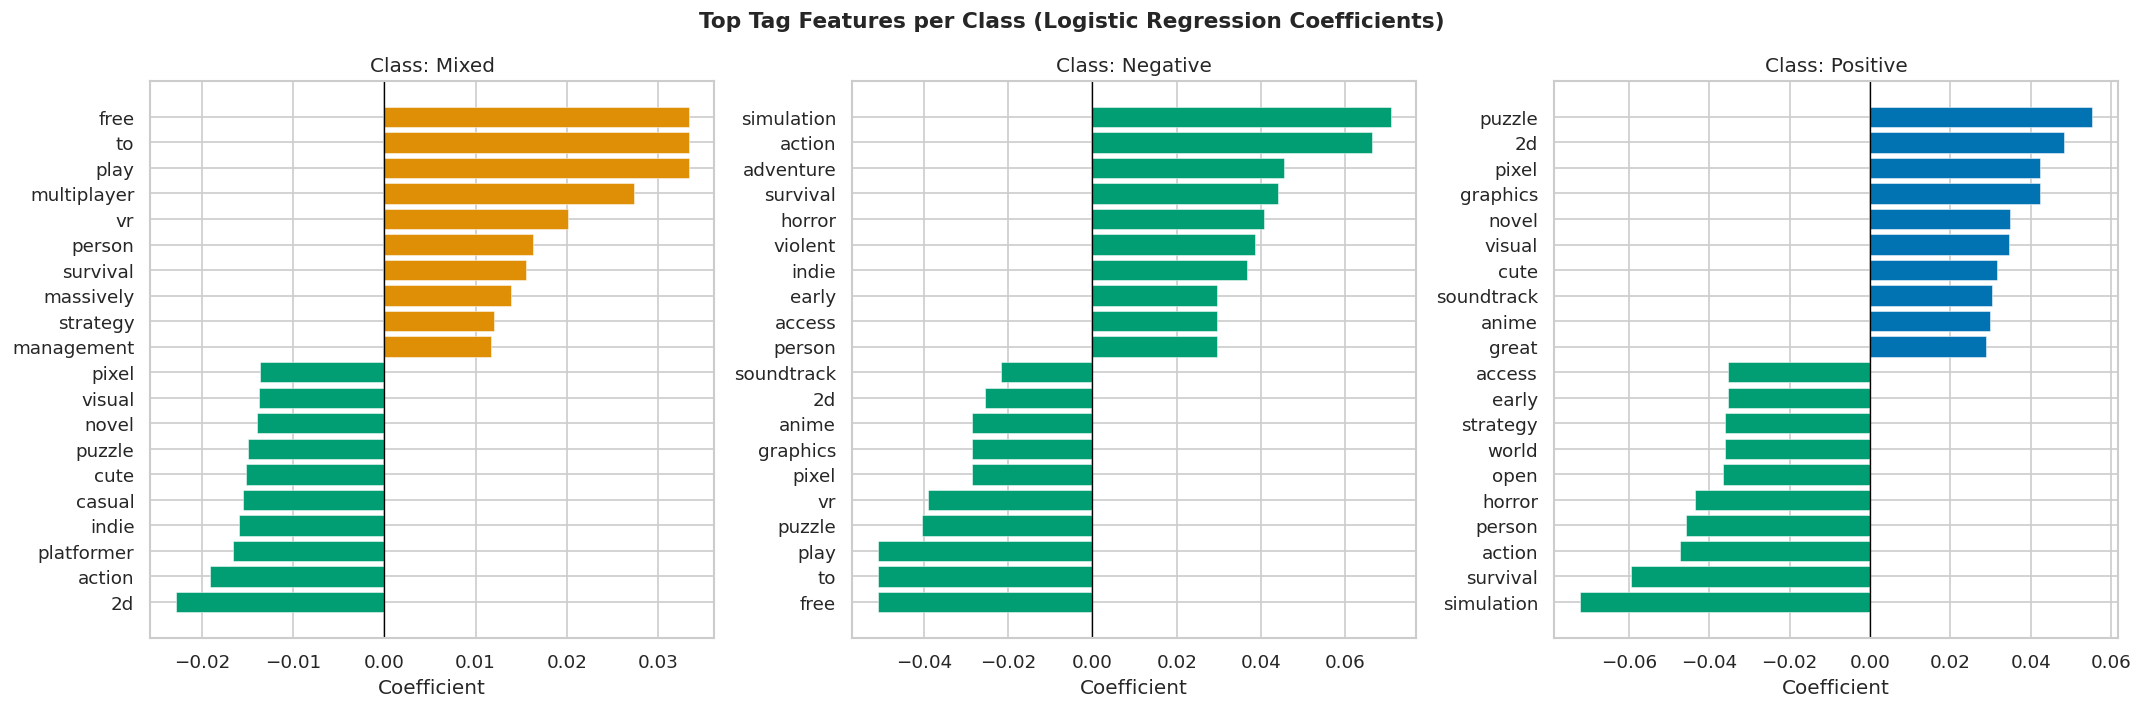

In [24]:
# Top TF-IDF tag coefficients per class from Logistic Regression (Combined)
all_feature_names = feature_cols + list(tfidf.get_feature_names_out())
classes_order     = lr_combined.classes_
tag_feature_names = list(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top Tag Features per Class (Logistic Regression Coefficients)',
             fontsize=13, fontweight='bold')

cls_palette = {'Mixed': C_MIXED, 'Negative': C_NEGATIVE, 'Positive': C_POSITIVE}

for i, cls in enumerate(classes_order):
    coefs      = pd.Series(lr_combined.coef_[i], index=all_feature_names)
    coefs_tags = coefs[tag_feature_names].sort_values(ascending=True)
    top_tags   = pd.concat([coefs_tags.head(10), coefs_tags.tail(10)])
    bar_c      = [C_NEGATIVE if v < 0 else cls_palette[cls] for v in top_tags.values]
    axes[i].barh(top_tags.index, top_tags.values,
                 color=bar_c, edgecolor='white', linewidth=0.3)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'Class: {cls}')
    axes[i].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

---
## 7. Impact of Community Tags

          Model  Macro F1  Accuracy
LR - Basic Only    0.3855    0.5129
 LR - With Tags    0.3897    0.5175
RF - Basic Only    0.4322    0.6977
 RF - With Tags    0.4765    0.6647


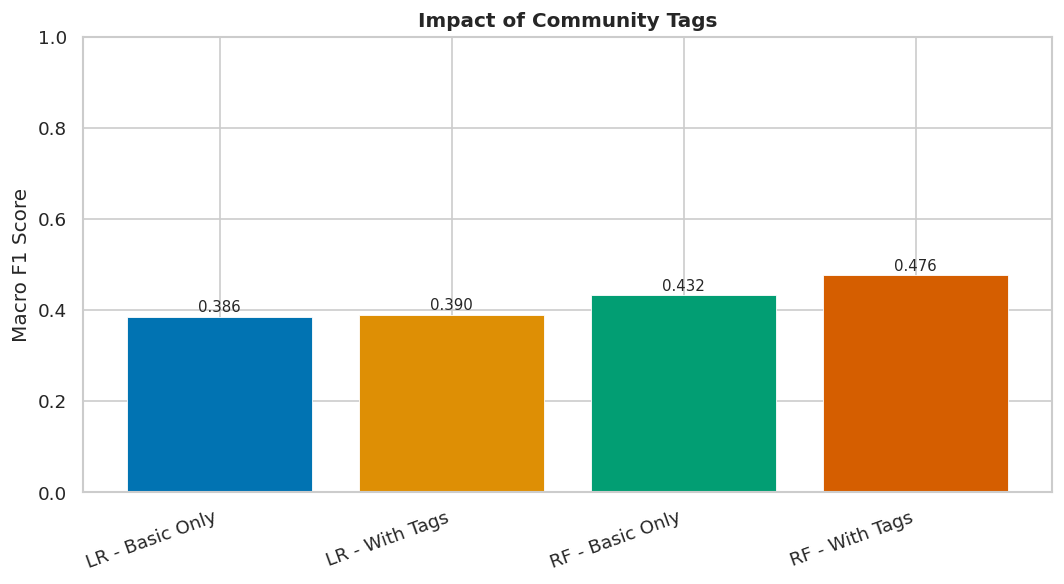

In [27]:
impact_data = [
    {'Model': 'LR - Basic Only', 'Macro F1': results[0]['macro_f1'], 'Accuracy': results[0]['accuracy']},
    {'Model': 'LR - With Tags',  'Macro F1': results[4]['macro_f1'], 'Accuracy': results[4]['accuracy']},
    {'Model': 'RF - Basic Only', 'Macro F1': results[2]['macro_f1'], 'Accuracy': results[2]['accuracy']},
    {'Model': 'RF - With Tags',  'Macro F1': results[3]['macro_f1'], 'Accuracy': results[3]['accuracy']},
]
impact_df = pd.DataFrame(impact_data)

print(impact_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
impact_colors = [C1, C2, C3, C4]
x    = np.arange(len(impact_df))
bars = ax.bar(x, impact_df['Macro F1'],
              color=impact_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(impact_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Macro F1 Score')
ax.set_title('Impact of Community Tags',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
for bar, val in zip(bars, impact_df['Macro F1']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Summary

In [26]:
print(results_df.sort_values('Macro F1', ascending=False).to_string(index=False))

best = results_df.sort_values('Macro F1', ascending=False).iloc[0]
print(f'\nBest model:    {best["Model"]}')
print(f'Best Macro F1: {best["Macro F1"]}')
print(f'Best Accuracy: {best["Accuracy"]}')

                                    Model  Accuracy  Macro F1  Weighted F1
      Random Forest (Basic + TF-IDF Tags)    0.6647    0.4765       0.6623
           Random Forest (Basic Features)    0.6977    0.4322       0.6518
           Decision Tree (Basic Features)    0.5056    0.4040       0.5530
Logistic Regression (Basic + TF-IDF Tags)    0.5175    0.3897       0.5576
     Logistic Regression (Basic Features)    0.5129    0.3855       0.5544

Best model:    Random Forest (Basic + TF-IDF Tags)
Best Macro F1: 0.4765
Best Accuracy: 0.6647
